# Inference – Pose from Cylinders

This notebook loads a trained checkpoint and reproduces the inference plots from `train.ipynb`:

1. Vision prediction for one sample (occupancy, radius, depth).
2. Estimated cylinders overlaid on the image pair.
3. Relative pose comparison (GT vs prediction).

The model architecture is read from the checkpoint so the inference model matches the trained model exactly.


In [1]:
%load_ext autoreload
%autoreload 2


In [2]:
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader

from dataset import SceneTwoPairsDataset
from model import PairImageCylinderModel
from utils import plot_estimated_cylinders_on_images, plot_relative_pose, pose_to_text

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CHECKPOINT = Path("arrhenius_runs/slurm_with_warm_up/checkpoints/latest.pt")
TEST_DATASET = Path("testdataset")
BATCH_SIZE = 4
SAMPLE_IDX = 0
OCC_THRESHOLD = 0.5

print("Device:", DEVICE)
if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA:", torch.version.cuda)
print("Checkpoint:", CHECKPOINT)
print("Test dataset:", TEST_DATASET)


Device: cuda
GPU: NVIDIA GeForce RTX 5050 Laptop GPU
CUDA: 13.0
Checkpoint: arrhenius_runs/slurm_with_warm_up/checkpoints/latest.pt
Test dataset: testdataset


In [3]:
checkpoint = torch.load(
    CHECKPOINT,
    map_location="cpu",
    weights_only=False,
)

args = checkpoint["args"]
print("Checkpoint epoch:", checkpoint["epoch"])
print("Model arguments:")
print(json.dumps(args, indent=2))

model = PairImageCylinderModel(
    img_size=args["img_size"],
    patch_size=args["patch_size"],
    in_chans=3,
    embed_dim=args["embed_dim"],
    depth=args["depth"],
    num_heads=args["num_heads"],
    num_bins=args["num_bins"],
    dropout=args["dropout"],
)

model.load_state_dict(checkpoint["model_state_dict"])
model = model.to(DEVICE)
model.eval()

print("Model loaded successfully.")


Checkpoint epoch: 200
Model arguments:
{
  "data_dir": "/nobackup/proj/disk/midlevel_representations/personal/johanna/data",
  "epochs": 300,
  "batch_size": 256,
  "lr": 0.001,
  "val_interval": 10,
  "img_size": 128,
  "patch_size": 8,
  "embed_dim": 384,
  "depth": 6,
  "num_heads": 6,
  "num_bins": 128,
  "dropout": 0.1,
  "lambda_occ": 10.0,
  "lambda_radius": 10.0,
  "occ_thresh": 0.5,
  "output_dir": "runs/slurm_2003039"
}
Model loaded successfully.


In [4]:
infer_dataset = SceneTwoPairsDataset(
    root_dir=str(TEST_DATASET),
    image_size=args["img_size"],
    return_two_pairs=False,
)

infer_loader = DataLoader(
    infer_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
)

print("Inference dataset size:", len(infer_dataset))


Inference dataset size: 56


In [5]:
batch = next(iter(infer_loader))
img_a, vision_a, img_b, vision_b, pose_ab = batch

img_a = img_a.to(DEVICE)
vision_a = vision_a.to(DEVICE)
img_b = img_b.to(DEVICE)
vision_b = vision_b.to(DEVICE)
pose_ab = pose_ab.to(DEVICE)

with torch.no_grad():
    pred_vision, pred_vision_b, pred_pose = model(img_a, img_b)

print("pred_vision shape:", pred_vision.shape)
print("pred_vision_b shape:", pred_vision_b.shape)
print("pred_pose shape:", pred_pose.shape)
print("GT pose:", pose_ab[SAMPLE_IDX].detach().cpu())
print("Pred pose:", pred_pose[SAMPLE_IDX].detach().cpu())


pred_vision shape: torch.Size([4, 128, 3])
pred_vision_b shape: torch.Size([4, 128, 3])
pred_pose shape: torch.Size([4, 4])
GT pose: tensor([0.8280, 0.5607, 0.0396, 0.9992])
Pred pose: tensor([-0.7644,  0.0081, -0.0103,  0.9999])


## 1. Vision prediction – same plot as `train.ipynb`


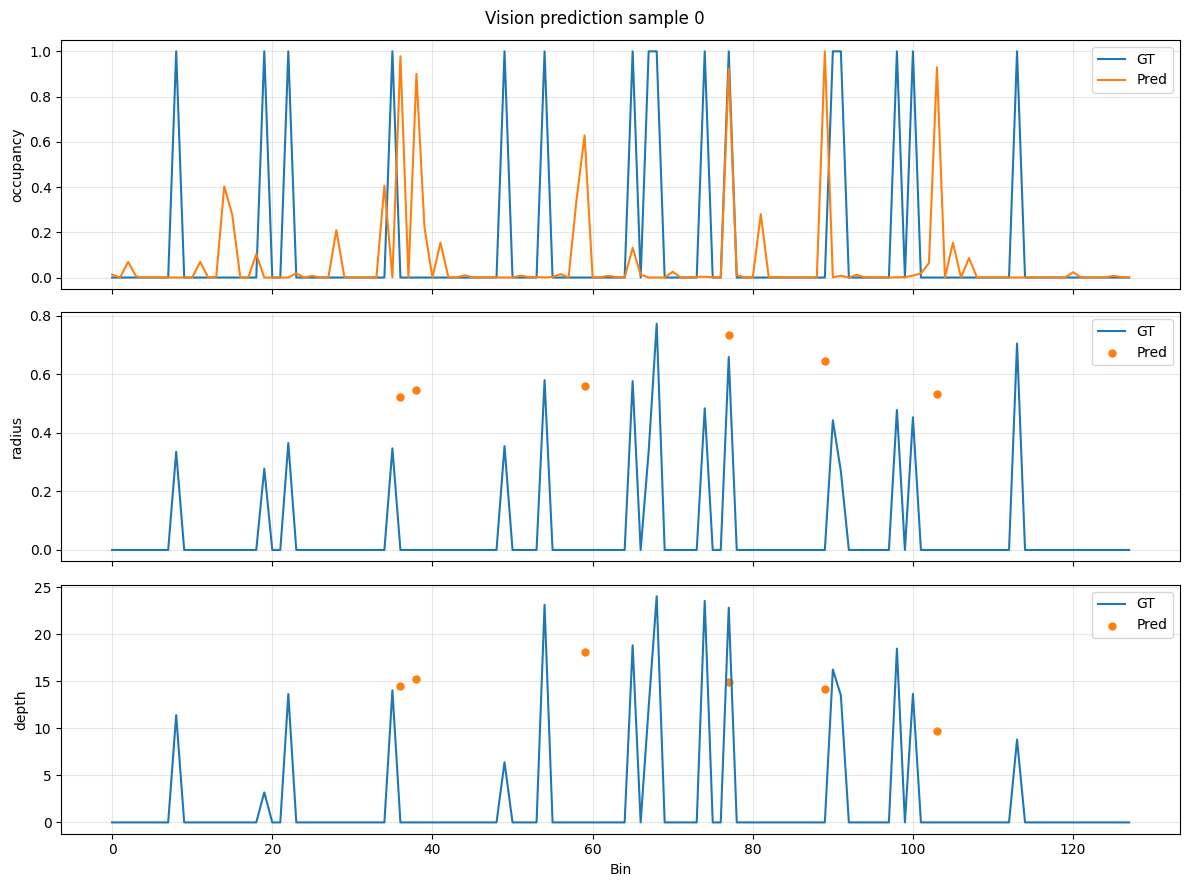

In [6]:
# Plotta vision-output för första samplet
sample_idx = SAMPLE_IDX
bins = np.arange(pred_vision.shape[1])

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

names = ["occupancy", "radius", "depth"]
occ_threshold = OCC_THRESHOLD

gt_occ = vision_a[sample_idx, :, 0].detach().cpu().numpy()
pr_occ = pred_vision[sample_idx, :, 0].detach().cpu().numpy()

for j, ax in enumerate(axes):
    gt = vision_a[sample_idx, :, j].detach().cpu().numpy()
    pr = pred_vision[sample_idx, :, j].detach().cpu().numpy()

    # GT alltid blå linje
    ax.plot(bins, gt, label="GT", color="tab:blue")

    if j == 0:
        # occupancy: pred som orange linje
        ax.plot(bins, pr, label="Pred", color="tab:orange")
    else:
        pr_mask = pr_occ > occ_threshold

        # pred som orange punkter
        ax.scatter(
            bins[pr_mask],
            pr[pr_mask],
            label="Pred",
            color="tab:orange",
            s=25
        )

    ax.set_ylabel(names[j])
    ax.grid(True, alpha=0.3)
    ax.legend()

axes[-1].set_xlabel("Bin")
fig.suptitle(f"Vision prediction sample {sample_idx}")
plt.tight_layout()
plt.show()


## 2. Estimated cylinders on the image pair – same plot as `train.ipynb`


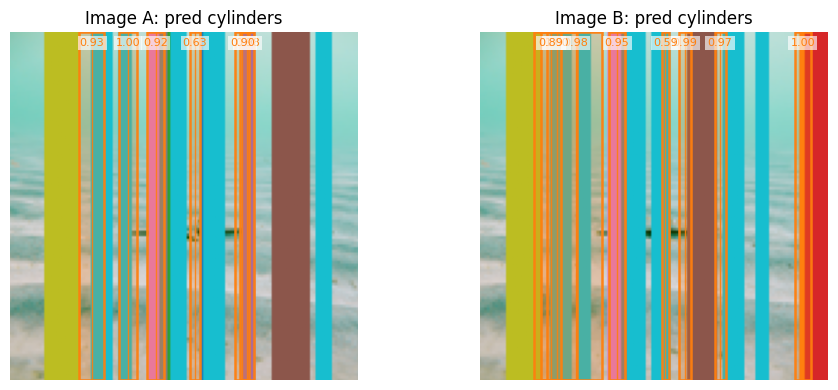

In [7]:
# Plotta bildpar med estimerade cylindrar
fig_cyl, axes_cyl = plot_estimated_cylinders_on_images(
    [img_a[sample_idx], img_b[sample_idx]],
    [pred_vision[sample_idx], pred_vision_b[sample_idx]],
    titles=["Image A: pred cylinders", "Image B: pred cylinders"],
    occ_threshold=occ_threshold,
    flip_x=True,
)
plt.show()


## 3. Relative pose – same plot as `train.ipynb`


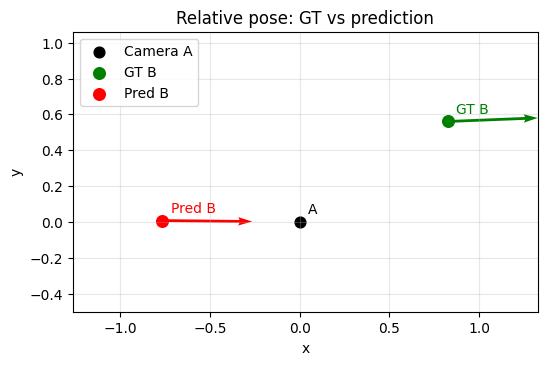

pred_vision shape: torch.Size([4, 128, 3])
pred_pose shape: torch.Size([4, 4])
GT pose: tensor([0.8280, 0.5607, 0.0396, 0.9992])
Pred pose: tensor([-0.7644,  0.0081, -0.0103,  0.9999])


In [8]:
# Visa relative pose
plot_relative_pose(pose_ab[sample_idx], pred_pose[sample_idx])

print("pred_vision shape:", pred_vision.shape)
print("pred_pose shape:", pred_pose.shape)
print("GT pose:", pose_ab[sample_idx].detach().cpu())
print("Pred pose:", pred_pose[sample_idx].detach().cpu())


## Optional: training history

This cell reproduces the training/validation loss plots from the training notebook when `history.json` is available next to the checkpoint. It is optional and does not affect inference.


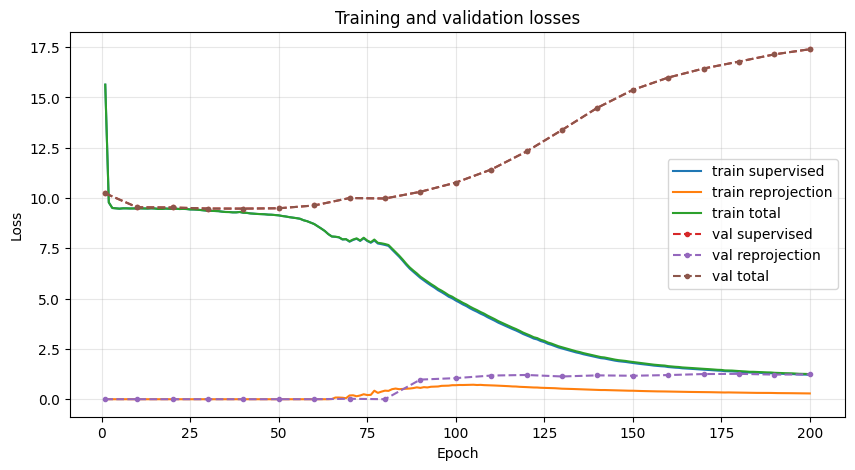

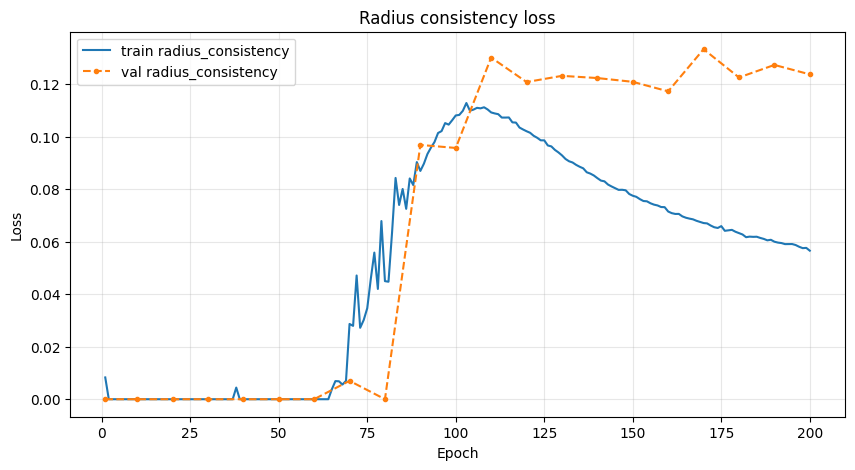

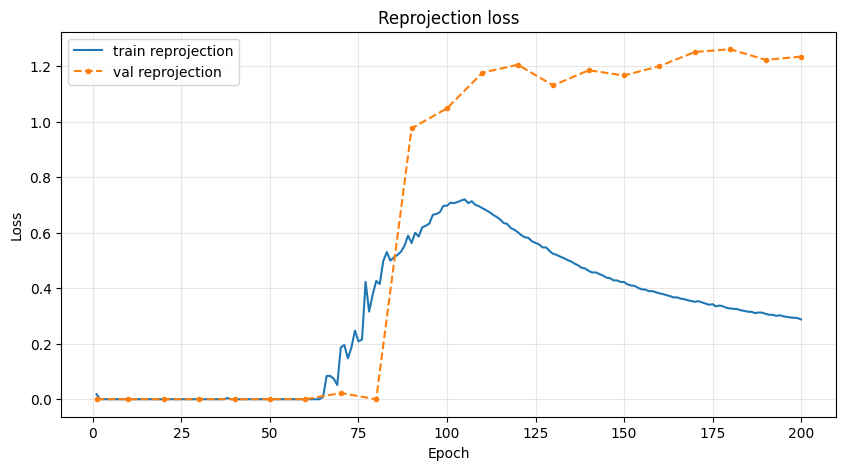

In [9]:
HISTORY = CHECKPOINT.parent.parent / "history.json"

if HISTORY.exists():
    with open(HISTORY, "r", encoding="utf-8") as f:
        history = json.load(f)

    # The Slurm train.py stores history as a list of epoch dictionaries.
    epochs = np.array([row["epoch"] for row in history])
    val_rows = [row for row in history if "val" in row]
    val_epochs = np.array([row["epoch"] for row in val_rows])

    train_total = np.array([row["train"]["total"] for row in history])
    train_supervised = np.array([row["train"]["supervised"] for row in history])
    train_reprojection = np.array([row["train"]["reprojection"] for row in history])
    train_radius = np.array([row["train"]["radius_consistency"] for row in history])

    val_total = np.array([row["val"]["total"] for row in val_rows])
    val_supervised = np.array([row["val"]["supervised"] for row in val_rows])
    val_reprojection = np.array([row["val"]["reprojection"] for row in val_rows])
    val_radius = np.array([row["val"]["radius_consistency"] for row in val_rows])

    # Training and validation losses
    plt.figure(figsize=(10, 5))
    plt.plot(epochs, train_supervised, label="train supervised")
    plt.plot(epochs, train_reprojection, label="train reprojection")
    plt.plot(epochs, train_total, label="train total")
    if len(val_epochs) > 0:
        plt.plot(val_epochs, val_supervised, ".--", label="val supervised")
        plt.plot(val_epochs, val_reprojection, ".--", label="val reprojection")
        plt.plot(val_epochs, val_total, ".--", label="val total")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training and validation losses")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    # Radius consistency
    plt.figure(figsize=(10, 5))
    plt.plot(epochs, train_radius, label="train radius_consistency")
    if len(val_epochs) > 0:
        plt.plot(val_epochs, val_radius, ".--", label="val radius_consistency")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Radius consistency loss")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    # Reprojection
    plt.figure(figsize=(10, 5))
    plt.plot(epochs, train_reprojection, label="train reprojection")
    if len(val_epochs) > 0:
        plt.plot(val_epochs, val_reprojection, ".--", label="val reprojection")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Reprojection loss")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print("No history.json found at:", HISTORY)
